<a href="https://colab.research.google.com/github/leonardomenezes10/Fundamentos/blob/main/notebooks/serpro/Serpro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução ao Pensamento computacional

## Ferramentas/Serviços utilizados

- Google Colab (notebook com codigo)
- Github (rede social de código)
- Git (programa de versionamento de código)


## Pilares
- Decomposição
- Abstração
- Identificação de padrões
- Lógica


## Noções Gerais

- Exemplos a partir de coleta de dados
  - Site MRE - Notas de imprensa
    - [x] Link do site: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa
    - [x] Entender a estrutura da fonte de informação
    - [ ] Realizar a coleta
    - [ ] Inserir as informações em um banco de dados
    - [ ] Utilizar as informações (analise de dados)


### Padrão de paginação das notas de imprensa
  - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=0
   - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=30
   - Pagina final (10/02/2026): 6210



## Importação de bibliotecas/pogramas utilizados neste arquivo

In [ ]:
!pip install tinydb

In [ ]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

## Criação do banco json

In [ ]:
def inserir_no_banco(dados, link_noticia):
  arquivo_banco_dados = "nota_serpro.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_noticia)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(dados)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

In [ ]:
for x in range (1, 1230, 30):
  paginas = (f'https://www.serpro.gov.br/listagem-noticias?b_start:int={x}')
  print(paginas)

https://www.serpro.gov.br/listagem-noticias?b_start:int=1
https://www.serpro.gov.br/listagem-noticias?b_start:int=31
https://www.serpro.gov.br/listagem-noticias?b_start:int=61
https://www.serpro.gov.br/listagem-noticias?b_start:int=91
https://www.serpro.gov.br/listagem-noticias?b_start:int=121
https://www.serpro.gov.br/listagem-noticias?b_start:int=151
https://www.serpro.gov.br/listagem-noticias?b_start:int=181
https://www.serpro.gov.br/listagem-noticias?b_start:int=211
https://www.serpro.gov.br/listagem-noticias?b_start:int=241
https://www.serpro.gov.br/listagem-noticias?b_start:int=271
https://www.serpro.gov.br/listagem-noticias?b_start:int=301
https://www.serpro.gov.br/listagem-noticias?b_start:int=331
https://www.serpro.gov.br/listagem-noticias?b_start:int=361
https://www.serpro.gov.br/listagem-noticias?b_start:int=391
https://www.serpro.gov.br/listagem-noticias?b_start:int=421
https://www.serpro.gov.br/listagem-noticias?b_start:int=451
https://www.serpro.gov.br/listagem-noticias?b

In [ ]:
# Variável e tipos de dados (string, lista, numero)

all_paginas_links = [] # Initialize as an empty list
for x in range (1, 1230, 30):
  url = (f'https://www.serpro.gov.br/listagem-noticias?b_start:int={x}')
  all_paginas_links.append(url) # Add each URL to the list

def acessa_pagina (link):
  print (f"Estamos na pagina:{link}")

  # Define headers para a requisição, simulando um navegador
  headers = {
      'User-Agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36",
      'Accept-Language': 'en-US,en;q=0.9',
      'Accept-Encoding': 'gzip, deflate, br',
      'Connection': 'keep-alive',
  }

  timeout = httpx.Timeout(connect=20.0, read=30.0, write=20.0, pool=10.0)
  pag_web = httpx.get(link, headers=headers, timeout=timeout)
  bs = BeautifulSoup(pag_web, "html.parser")
  return bs

# loop for
# beautifulsoap >> find e find_all

# Now, iterate over the list of URLs
for pagina in all_paginas_links:
  pagina_inteira = acessa_pagina(pagina)
  lista_noticias = pagina_inteira.find("div", attrs={"id": "list-container"}).find_all("div", attrs={"class": "group-detail-notice"})
  print(f"Quantidade de notícias encontradas: {len(lista_noticias)}")
  for noticia in lista_noticias:
    # titulo
    try:
      titulo = noticia.find("h2", attrs={"class": "lista-titulo-noticia"}).text.strip()
      print(titulo)
    except:
        titulo = ""

    #link
    try:
      link_noticia = noticia.a["href"]
      print(link_noticia)
    except:
      link_noticia = ""

    try:
      tema = noticia.find("span", attrs={"class": "lista-image-caption-noticia"}).text.strip()
      print(tema)
    except:
      tema = ""

    # data
    data = noticia.find("div", attrs={"class": "lista-data-noticia"}).text.strip()

    # horário
    hora = noticia.find("div", attrs={"class": "lista-hora-noticia"}).text.strip()

    print(data)
    print(hora)


    conteudo = acessa_pagina (link_noticia)
    paragrafos = conteudo.find("div", attrs={"property":"rnews:articleBody"}).find_all("p")
    lista_paragrafos = []
    for paragrafo in paragrafos:
      lista_paragrafos.append(paragrafo.text.strip())
    print(lista_paragrafos)

    print("###")
    #função para inserir dados coletados no banco
    dados = {
        "titulo": titulo,
        "link": link_noticia,
        "data": data,
        "hora": hora,
        "num_nota": tema,
        "paragrafo": lista_paragrafos
    }
    inserir_no_banco(dados,link_noticia)

A saída de streaming foi truncada nas últimas 5000 linhas.
22/08/2024
15:31
Estamos na pagina:https://www.serpro.gov.br/menu/noticias/noticias-2024/serpro-ficha-hospedes
['Dezenove hotéis do país já começaram a testar o novo modelo digital da Ficha Nacional de Registro de Hóspede (FNRH). Com a tecnologia, o turista que chega para preencher seus dados no check-in já pode acessar a versão eletrônica da ficha, reduzindo consideravelmente o tempo de espera dos hóspedes. A inovação também melhora a segurança e permite um gerenciamento mais eficiente dos dados turísticos, além de simplificar o\xa0envio das informações exigidas pela Lei Geral do Turismo.', 'O objetivo dessa primeira fase do projeto é avaliar as novas funcionalidades da Ficha Nacional de Registro de Hóspede e corrigir quaisquer dissonâncias. Os hotéis foram indicados pelas entidades que compõe o Conselho Nacional de Turismo e a meta é implantar a versão digital da FNRH em toda rede hoteleira do Brasil até\xa0 2025.', 'A ficha 

# Transformar banco json e dataframe

- pre-analise - entendimento geral sobre o dataframe

In [ ]:
import pandas as pd
import json

## Abrindo o rquivo json
with open("nota_serpro.json") as f:
  raw = json.load(f)

df = pd.DataFrame.from_dict(raw["_default"], orient="index")

df


,titulo,link,data,hora,num_nota,paragrafo
1,Reforma tributária pauta encontro internaciona...,https://www.serpro.gov.br/menu/noticias/notici...,01/06/2026,16:26,Debate,"[Mais de 600 auditores fiscais de Brasil, Port..."
2,Serpro garante infraestrutura tecnológica da T...,https://www.serpro.gov.br/menu/noticias/notici...,01/06/2026,15:26,Cultura,[Com infraestrutura tecnológica fornecida pelo...
3,Tecnologia do Serpro garante mais um recorde n...,https://www.serpro.gov.br/menu/noticias/notici...,29/05/2026,23:31,Recorde,[Mais de 44 milhões de declarações enviadas de...
4,Gov.br é tema do novo episódio do Serprocast,https://www.serpro.gov.br/menu/noticias/notici...,29/05/2026,16:11,Vida Digital,[Como funciona a conta Gov.br? Por que existem...
5,Confiança digital exige cultura antifraude e r...,https://www.serpro.gov.br/menu/noticias/notici...,28/05/2026,16:30,Conscientização,[A digitalização crescente dos serviços públic...
...,...,...,...,...,...,...
1227,Tecnologia mapeia imóveis urbanos e rurais do ...,https://www.serpro.gov.br/menu/noticias/notici...,09/12/2022,11:24,Eficiência,"[Em evento realizado nesta quinta-feira, 8 de ..."
1228,“O Ministério da Infraestrutura jamais avançar...,https://www.serpro.gov.br/menu/noticias/notici...,08/12/2022,18:48,Reconhecimento,[“Nós jamais avançaríamos na agenda da transfo...
1229,Livro do Serpro inova ao priorizar a governanç...,https://www.serpro.gov.br/menu/noticias/notici...,08/12/2022,01:24,Lançamento,[“A governança da privacidade e da proteção de...
1230,Tecnologia auxilia o Brasil no combate ao desm...,https://www.serpro.gov.br/menu/noticias/notici...,07/12/2022,18:28,Meio Ambiente,[O Instituto Brasileiro do Meio Ambiente e dos...


In [ ]:
# saber quantidade de linhas e colunas do dataframe
df.shape

(1231, 6)

In [ ]:
# saber colunas disponiveis
df.columns

Index(['titulo', 'link', 'data', 'hora', 'num_nota', 'paragrafo'], dtype='object')

In [ ]:
# selecionar uma coluna em especifico
df["titulo"]

,titulo
1,Reforma tributária pauta encontro internaciona...
2,Serpro garante infraestrutura tecnológica da T...
3,Tecnologia do Serpro garante mais um recorde n...
4,Gov.br é tema do novo episódio do Serprocast
5,Confiança digital exige cultura antifraude e r...
...,...
1227,Tecnologia mapeia imóveis urbanos e rurais do ...
1228,“O Ministério da Infraestrutura jamais avançar...
1229,Livro do Serpro inova ao priorizar a governanç...
1230,Tecnologia auxilia o Brasil no combate ao desm...


In [ ]:

# delimitar colunas do dataframe
df_delimitado = df[["titulo", "data"]]
df_delimitado

,titulo,data
1,Reforma tributária pauta encontro internaciona...,01/06/2026
2,Serpro garante infraestrutura tecnológica da T...,01/06/2026
3,Tecnologia do Serpro garante mais um recorde n...,29/05/2026
4,Gov.br é tema do novo episódio do Serprocast,29/05/2026
5,Confiança digital exige cultura antifraude e r...,28/05/2026
...,...,...
1227,Tecnologia mapeia imóveis urbanos e rurais do ...,09/12/2022
1228,“O Ministério da Infraestrutura jamais avançar...,08/12/2022
1229,Livro do Serpro inova ao priorizar a governanç...,08/12/2022
1230,Tecnologia auxilia o Brasil no combate ao desm...,07/12/2022


In [ ]:

# primeiras (head), ultimas (tail) e linhas aleatórias (sample)
df.head(10)

,titulo,link,data,hora,num_nota,paragrafo
1,Reforma tributária pauta encontro internaciona...,https://www.serpro.gov.br/menu/noticias/notici...,01/06/2026,16:26,Debate,"[Mais de 600 auditores fiscais de Brasil, Port..."
2,Serpro garante infraestrutura tecnológica da T...,https://www.serpro.gov.br/menu/noticias/notici...,01/06/2026,15:26,Cultura,[Com infraestrutura tecnológica fornecida pelo...
3,Tecnologia do Serpro garante mais um recorde n...,https://www.serpro.gov.br/menu/noticias/notici...,29/05/2026,23:31,Recorde,[Mais de 44 milhões de declarações enviadas de...
4,Gov.br é tema do novo episódio do Serprocast,https://www.serpro.gov.br/menu/noticias/notici...,29/05/2026,16:11,Vida Digital,[Como funciona a conta Gov.br? Por que existem...
5,Confiança digital exige cultura antifraude e r...,https://www.serpro.gov.br/menu/noticias/notici...,28/05/2026,16:30,Conscientização,[A digitalização crescente dos serviços públic...
6,Reforma Tributária do Consumo ganha novos sist...,https://www.serpro.gov.br/menu/noticias/notici...,28/05/2026,11:29,Modernização,"[O Serpro e a Receita Federal lançam, em maio ..."
7,"Em São Paulo, Receita Federal e Serpro realiza...",https://www.serpro.gov.br/menu/noticias/notici...,28/05/2026,10:08,Aviso de Pauta,"[A Receita Federal e o Serpro realizam, nesta ..."
8,Tecnologia pública brasileira de validação de ...,https://www.serpro.gov.br/menu/noticias/notici...,28/05/2026,03:13,Internacional,"[O Serpro, empresa estatal de inteligência em ..."
9,"Há 50 anos, a RAIS ajuda o Estado brasileiro a...",https://www.serpro.gov.br/menu/noticias/notici...,27/05/2026,18:29,Sociedade,"[Há meio século, a Relação Anual de Informaçõe..."
10,20 anos do e-Processo: das Kombis a uma infrae...,https://www.serpro.gov.br/menu/noticias/notici...,27/05/2026,11:05,Tecnologia,"[A administração tributária brasileira, em bus..."


In [ ]:
df.describe(include="all")

,titulo,link,data,hora,num_nota,paragrafo
count,1231,1231,1231,1231,1231,1231
unique,1229,1231,668,608,424,1231
top,CNH do Brasil é a evolução da Carteira Digital...,https://www.serpro.gov.br/menu/noticias/notici...,16/10/2025,16:27,Inovação,[Criado para aumentar a eficiência dos portos ...
freq,2,1,6,8,83,1


In [ ]:
df.isnull().sum()

,0
titulo,0
link,0
data,0
hora,0
num_nota,0
paragrafo,0


### Tratamento de Dados e Visualização

Agora que entendemos a estrutura, vamos preparar os dados para extrair insights visuais. Um passo comum é converter colunas de texto em formatos que o computador entenda como 'tempo' (datetime) e criar gráficos.

In [ ]:
# 1. Converter a coluna de data para o formato datetime do Pandas
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)

# 2. Contar quantas notícias temos por dia
noticias_por_dia = df['data_dt'].value_counts().sort_index()

display(noticias_por_dia)

,count
data_dt,
2022-12-07,2
2022-12-08,2
2022-12-09,1
2022-12-11,1
2022-12-13,2
...,...
2026-05-26,2
2026-05-27,2
2026-05-28,4


#### Visualizando o Volume de Publicações

Vamos usar a biblioteca `matplotlib` (que já vem no ambiente) para criar um gráfico de barras simples.

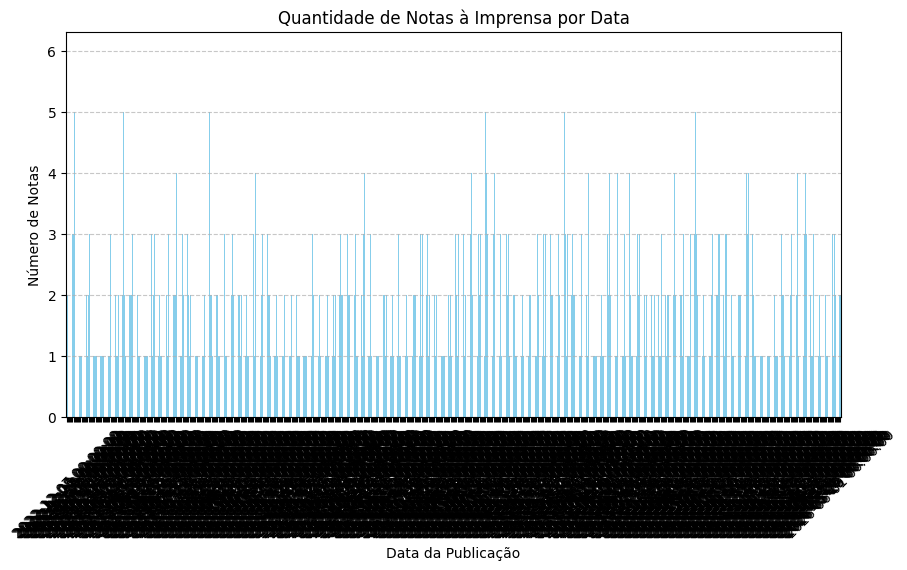

In [ ]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(10, 5))
noticias_por_dia.plot(kind='bar', color='skyblue')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Data')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Analisando Palavras-Chave nos Títulos

Uma técnica simples de análise de texto para iniciantes é verificar a frequência de certas palavras-chave (como nomes de países).

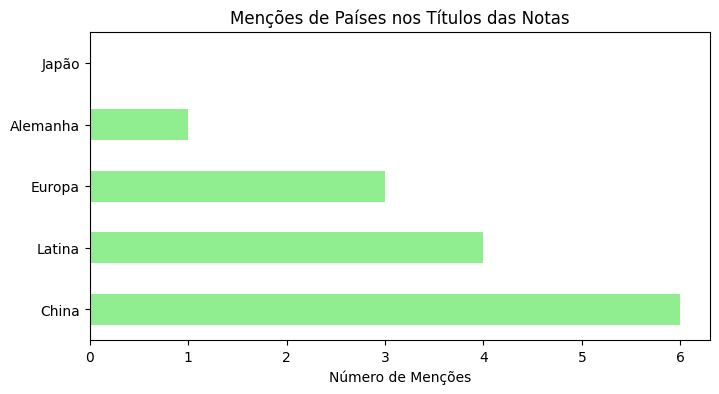

In [ ]:
paises = ['Alemanha', 'China', 'Japão', 'Europa', 'Latina']
frequencia = {}

for pais in paises:
    # Conta em quantos títulos a palavra aparece
    frequencia[pais] = df['titulo'].str.contains(pais, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções de Países nos Títulos das Notas')
plt.xlabel('Número de Menções')
plt.show()

---

# 📊 Visualização avançada dos dados

Nesta parte vamos:

1. **Preparar** os dados (corrigir tipos, criar colunas auxiliares)
2. **Buscar** por termos e palavras-chave (no título e no corpo da nota)
3. **Analisar** frequência de termos (países, temas, organizações)
4. **Visualizar** o volume de publicações no tempo
5. **Acompanhar** um tema específico ao longo do tempo
6. **Gerar** nuvens de palavras (word cloud)
7. **Examinar** o tamanho das notas
8. **Descobrir** co-ocorrências (quais países aparecem juntos)


## 1. Preparação dos dados

Antes de visualizar, precisamos arrumar algumas coisas:

- A coluna `data` está como **texto** (`"22/04/2026"`). Vamos transformar em **datetime** para conseguir agrupar por mês, dia da semana, etc.
- A coluna `paragrafo` contém **listas** de strings — por isso `df.duplicated()` deu erro mais acima. Vamos juntar os parágrafos em um único texto na coluna `texto`.
- Vamos criar uma coluna `texto_completo` com título + corpo, em minúsculas, para facilitar buscas case-insensitive.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafo'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafo'] = df['paragrafo'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'qtd_paragrafo', 'tamanho_texto']].head()


Total de notas: 1231
Período: de 2022-12-07 até 2026-06-01


,titulo,data_dt,qtd_paragrafo,tamanho_texto
1,Reforma tributária pauta encontro internaciona...,2026-06-01,20,5795
2,Serpro garante infraestrutura tecnológica da T...,2026-06-01,10,3506
3,Tecnologia do Serpro garante mais um recorde n...,2026-05-29,12,4749
4,Gov.br é tema do novo episódio do Serprocast,2026-05-29,7,1830
5,Confiança digital exige cultura antifraude e r...,2026-05-28,17,4368


### 1.1 Verificar duplicatas

Como a coluna `paragrafo` é uma lista, ela quebra o `df.duplicated()`. Solução: verificar duplicatas só nas colunas que importam (link, título).


In [ ]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())


Duplicatas por link: 0
Duplicatas por título: 2


## 2. 🔍 Busca por termos e palavras-chave

A busca anterior só olhava o **título**. Vamos criar uma função que busca no **título e/ou no corpo** da nota, mostrando quantas notas mencionam o termo e permitindo ver os resultados.


In [ ]:
def buscar_termo(termo, onde='completo', mostrar=5):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)
        mostrar (int): quantos resultados imprimir

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df)} ({len(resultado)/len(df)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.head(mostrar).iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    if len(resultado) > mostrar:
        print(f"  ... e mais {len(resultado) - mostrar} nota(s)")

    return resultado


# Exemplos de uso:
res = buscar_termo('China', onde='completo', mostrar=5)


🔎 Termo: 'China'  |  Onde: completo
📌 Notas encontradas: 25 de 1231 (2.0%)
------------------------------------------------------------
  • [25/05/2026] Serpro busca referência internacional para fortalecer sua Universidade Corporativa
  • [13/04/2026] Governo firma acordo com China para desenvolver capacidade nacional de IA e sustentar a inteligência do Estado
  • [21/03/2026] Serpro ganha destaque internacional em evento na China e reforça liderança em nuvem soberana
  • [02/03/2026] Governo estrutura capacidade nacional de IA para sustentar a inteligência do Estado
  • [22/01/2026] Serpro recebe visita do embaixador do Nepal
  ... e mais 20 nota(s)


In [ ]:
# Buscar só no título
buscar_termo('China', onde='titulo', mostrar=5)


🔎 Termo: 'China'  |  Onde: titulo
📌 Notas encontradas: 6 de 1231 (0.5%)
------------------------------------------------------------
  • [13/04/2026] Governo firma acordo com China para desenvolver capacidade nacional de IA e sustentar a inteligência do Estado
  • [21/03/2026] Serpro ganha destaque internacional em evento na China e reforça liderança em nuvem soberana
  • [04/08/2025] Brasil e China aprofundam cooperação em governo digital com participação estratégica do Serpro
  • [29/07/2025] Serpro representa o Brasil na China e fortalece protagonismo em inteligência pública e governo digital
  • [03/04/2025] Serpro amplia domínio técnico e visão estratégica em missão à China
  ... e mais 1 nota(s)


,titulo,link,data,hora,num_nota,paragrafo,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafo
48,Governo firma acordo com China para desenvolve...,https://www.serpro.gov.br/menu/noticias/notici...,13/04/2026,09:31,Cooperação Internacional,"[O Governo Federal formalizou, na última sexta...",2026-04-13,"O Governo Federal formalizou, na última sexta-...",governo firma acordo com china para desenvolve...,2026-04,Monday,5716,14
67,Serpro ganha destaque internacional em evento ...,https://www.serpro.gov.br/menu/noticias/notici...,21/03/2026,21:38,Reconhecimento,"[Durante o Huawei Cloud Compass 2026, realizad...",2026-03-21,"Durante o Huawei Cloud Compass 2026, realizado...",serpro ganha destaque internacional em evento ...,2026-03,Saturday,3658,11
309,Brasil e China aprofundam cooperação em govern...,https://www.serpro.gov.br/menu/noticias/notici...,04/08/2025,11:24,Internacional,[Em desdobramento à missão oficial do governo ...,2025-08-04,Em desdobramento à missão oficial do governo b...,brasil e china aprofundam cooperação em govern...,2025-08,Monday,4182,12
314,Serpro representa o Brasil na China e fortalec...,https://www.serpro.gov.br/menu/noticias/notici...,29/07/2025,14:05,Internacional,[O Serpro participa da missão oficial do gover...,2025-07-29,O Serpro participa da missão oficial do govern...,serpro representa o brasil na china e fortalec...,2025-07,Tuesday,4416,11
432,Serpro amplia domínio técnico e visão estratég...,https://www.serpro.gov.br/menu/noticias/notici...,03/04/2025,09:11,Nuvem de Governo,[Com foco no fortalecimento da soberania digit...,2025-04-03,Com foco no fortalecimento da soberania digita...,serpro amplia domínio técnico e visão estratég...,2025-04,Thursday,5047,11
583,Serpro fortalece presença internacional na Chi...,https://www.serpro.gov.br/menu/noticias/notici...,14/11/2024,11:13,Internacional,[O Serpro participou da China International Im...,2024-11-14,O Serpro participou da China International Imp...,serpro fortalece presença internacional na chi...,2024-11,Thursday,3879,9


In [ ]:
# Buscar uma expressão composta
buscar_termo('China', onde='completo', mostrar=5)


🔎 Termo: 'China'  |  Onde: completo
📌 Notas encontradas: 25 de 1231 (2.0%)
------------------------------------------------------------
  • [25/05/2026] Serpro busca referência internacional para fortalecer sua Universidade Corporativa
  • [13/04/2026] Governo firma acordo com China para desenvolver capacidade nacional de IA e sustentar a inteligência do Estado
  • [21/03/2026] Serpro ganha destaque internacional em evento na China e reforça liderança em nuvem soberana
  • [02/03/2026] Governo estrutura capacidade nacional de IA para sustentar a inteligência do Estado
  • [22/01/2026] Serpro recebe visita do embaixador do Nepal
  ... e mais 20 nota(s)


,titulo,link,data,hora,num_nota,paragrafo,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafo
14,Serpro busca referência internacional para for...,https://www.serpro.gov.br/menu/noticias/notici...,25/05/2026,17:03,Internacional,[Referência global em educação corporativa apl...,2026-05-25,Referência global em educação corporativa apli...,serpro busca referência internacional para for...,2026-05,Monday,2113,4
48,Governo firma acordo com China para desenvolve...,https://www.serpro.gov.br/menu/noticias/notici...,13/04/2026,09:31,Cooperação Internacional,"[O Governo Federal formalizou, na última sexta...",2026-04-13,"O Governo Federal formalizou, na última sexta-...",governo firma acordo com china para desenvolve...,2026-04,Monday,5716,14
67,Serpro ganha destaque internacional em evento ...,https://www.serpro.gov.br/menu/noticias/notici...,21/03/2026,21:38,Reconhecimento,"[Durante o Huawei Cloud Compass 2026, realizad...",2026-03-21,"Durante o Huawei Cloud Compass 2026, realizado...",serpro ganha destaque internacional em evento ...,2026-03,Saturday,3658,11
100,Governo estrutura capacidade nacional de IA pa...,https://www.serpro.gov.br/menu/noticias/notici...,02/03/2026,15:00,PBIA,"[O Governo do Brasil avançou, ao longo do mês ...",2026-03-02,"O Governo do Brasil avançou, ao longo do mês d...",governo estrutura capacidade nacional de ia pa...,2026-03,Monday,4807,9
117,Serpro recebe visita do embaixador do Nepal,https://www.serpro.gov.br/menu/noticias/notici...,22/01/2026,13:55,Internacionalização,"[O embaixador do Nepal, Nirmal Raj Kafle, visi...",2026-01-22,"O embaixador do Nepal, Nirmal Raj Kafle, visit...",serpro recebe visita do embaixador do nepal o ...,2026-01,Thursday,2945,7
152,De quem são os dados do Brasil?,https://www.serpro.gov.br/menu/noticias/notici...,05/12/2025,11:59,Soberania,[O uso massivo de dados passou a definir desde...,2025-12-05,O uso massivo de dados passou a definir desde ...,de quem são os dados do brasil? o uso massivo ...,2025-12,Friday,5721,12
159,Especialistas discutem oportunidades e riscos ...,https://www.serpro.gov.br/menu/noticias/notici...,03/12/2025,15:13,Futuro,[Em um momento em que a inteligência artificia...,2025-12-03,Em um momento em que a inteligência artificial...,especialistas discutem oportunidades e riscos ...,2025-12,Wednesday,4242,13
163,61 anos de protagonismo na inteligência do gov...,https://www.serpro.gov.br/menu/noticias/notici...,01/12/2025,07:36,Aniversário do Serpro,"[Nesse ano de 2025, ao completar 61 anos, o Se...",2025-12-01,"Nesse ano de 2025, ao completar 61 anos, o Ser...",61 anos de protagonismo na inteligência do gov...,2025-12,Monday,7863,23
226,Inteligência artificial em foco: caminhos para...,https://www.serpro.gov.br/menu/noticias/notici...,13/10/2025,16:19,Conhecimento,[O Serpro assume um papel de protagonismo na a...,2025-10-13,O Serpro assume um papel de protagonismo na ar...,inteligência artificial em foco: caminhos para...,2025-10,Monday,4744,10
309,Brasil e China aprofundam cooperação em govern...,https://www.serpro.gov.br/menu/noticias/notici...,04/08/2025,11:24,Internacional,[Em desdobramento à missão oficial do governo ...,2025-08-04,Em desdobramento à missão oficial do governo b...,brasil e china aprofundam cooperação em govern...,2025-08,Monday,4182,12


## 3. 📈 Frequência de vários termos comparados

Vamos generalizar a análise: em vez de fixar 5 países, comparamos qualquer lista de termos de interesse (países, organizações, temas) — buscando no texto **completo** (não só no título).


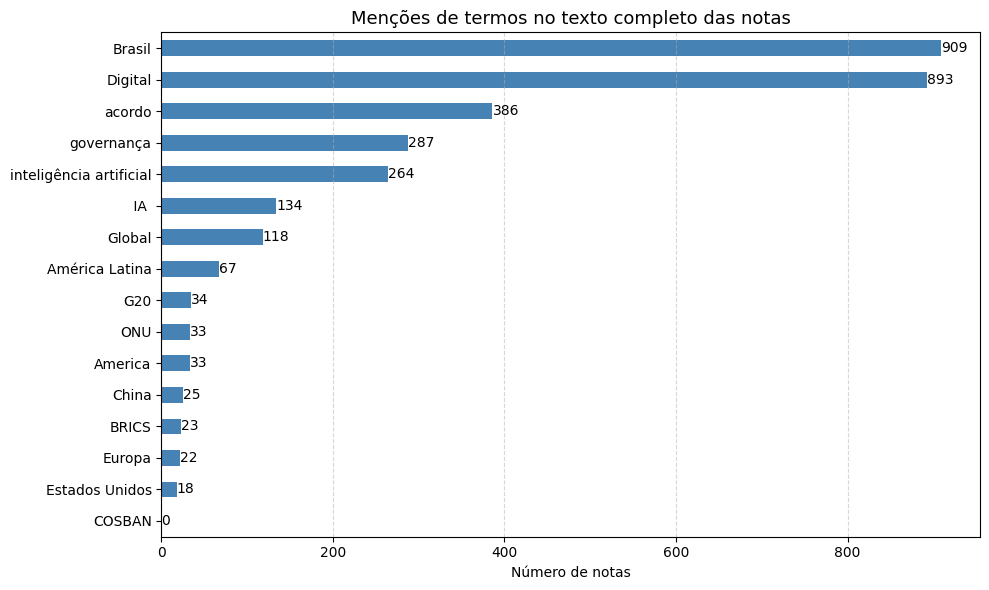

In [ ]:
def frequencia_termos(lista_termos, onde='completo'):
    """Conta em quantas notas cada termo da lista aparece."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    freq = {}
    for termo in lista_termos:
        freq[termo] = df[coluna].str.contains(termo, case=False, na=False, regex=False).sum()
    return pd.Series(freq).sort_values(ascending=True)


# Lista mais ampla de países e temas
termos_interesse = [
    'governança', ' IA ', 'inteligência artificial', 'Brasil', 'Global', 'acordo' ,
    'BRICS', 'China', 'G20', 'América Latina', 'America',
    'Digital', 'ONU', 'Europa', 'Estados Unidos', 'Europa', 'COSBAN'
]

freq = frequencia_termos(termos_interesse, onde='completo')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
freq.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Menções de termos no texto completo das notas', fontsize=13)
ax.set_xlabel('Número de notas')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores nas barras
for i, valor in enumerate(freq.values):
    ax.text(valor + 0.1, i, str(valor), va='center')

plt.tight_layout()
plt.show()


## 4. 🧠 Extração automática de palavras mais frequentes

Em vez de **definirmos** os termos, deixamos os dados falarem: quais palavras aparecem mais nos títulos? Para isso precisamos remover as **stopwords** (palavras muito comuns como "de", "da", "para") e palavras curtas.


Top 20 palavras nos TÍTULOS:
  serpro                    712
  digital                   190
  brasil                    96
  governo                   93
  tecnologia                85
  inovação                  74
  nacional                  68
  gestão                    66
  dados                     61
  inteligência              57
  transformação             45
  nuvem                     44
  nova                      43
  federal                   42
  municípios                40
  pública                   39
  parceria                  38
  serviços                  38
  artificial                37
  público                   36


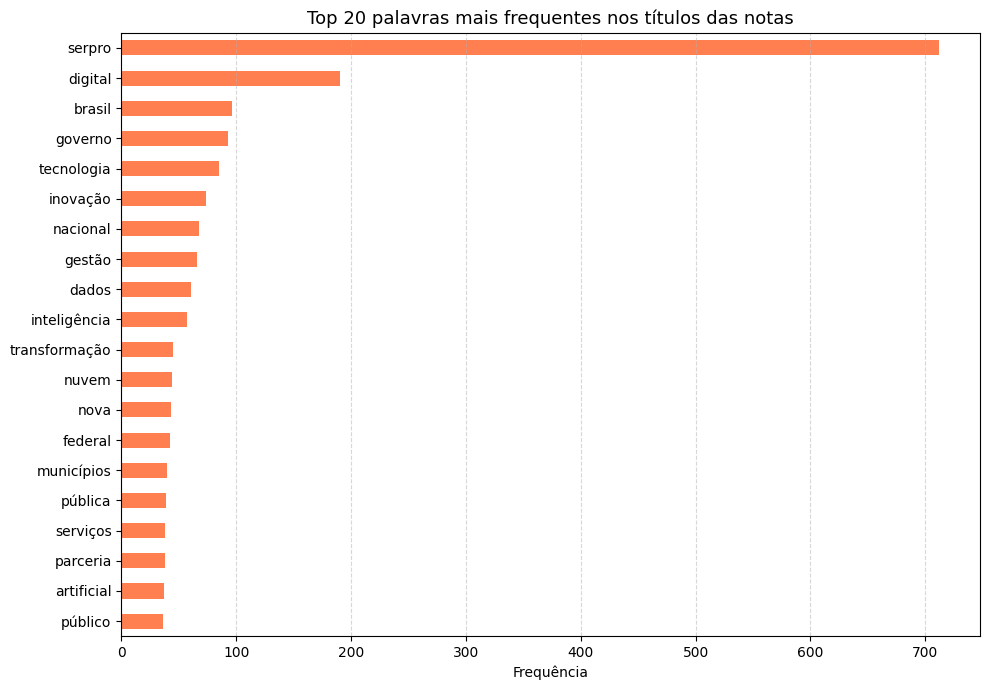

In [ ]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa', 'mais', 'como', 'lança', 'nova'
    'federal', 'evento'  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. 🗓️ Análise temporal

O gráfico anterior ("notas por dia") fica difícil de ler quando há muitas datas. Vamos olhar em **agregações** mais úteis: por mês, por dia da semana, e por hora do dia.


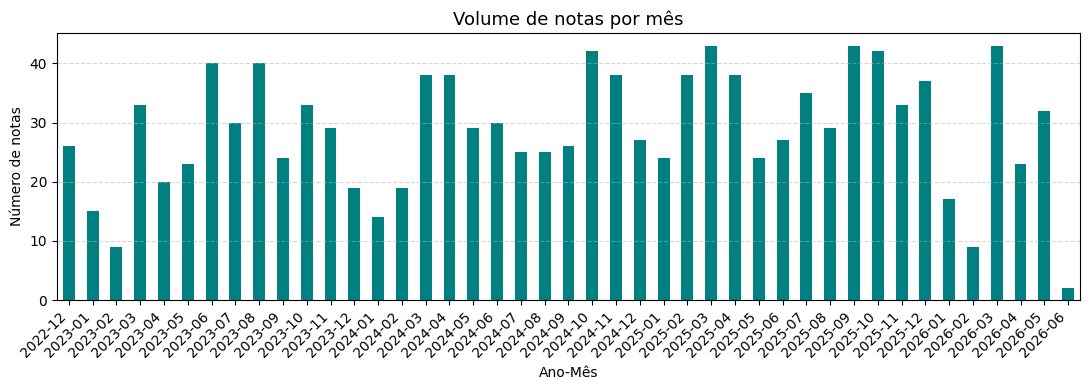

In [ ]:
# Notas por mês
notas_por_mes = df.groupby('ano_mes').size()

notas_por_mes

fig, ax = plt.subplots(figsize=(11, 4))
notas_por_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Volume de notas por mês', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


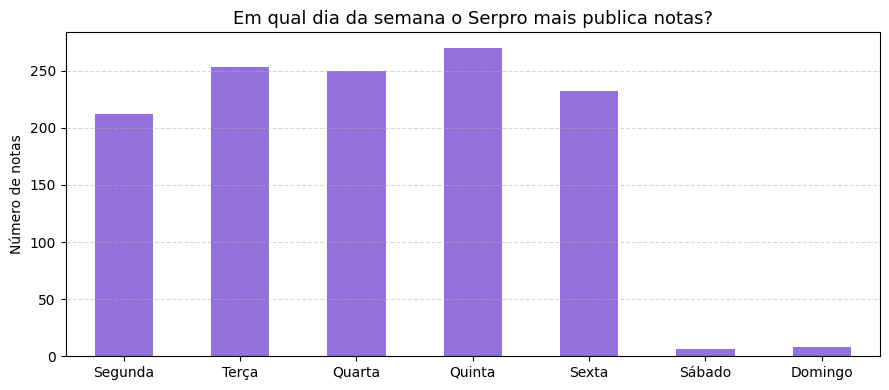

In [ ]:
# Notas por dia da semana (em português)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traducao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

por_dia_semana = df['dia_semana'].value_counts().reindex(ordem_dias).fillna(0)
por_dia_semana.index = [traducao_dias[d] for d in por_dia_semana.index]

fig, ax = plt.subplots(figsize=(9, 4))
por_dia_semana.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Em qual dia da semana o Serpro mais publica notas?', fontsize=13)
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. 📅 Acompanhar um tema ao longo do tempo

Combinando busca por termo + análise temporal: como evoluiu a menção a um país ou tema ao longo dos meses?


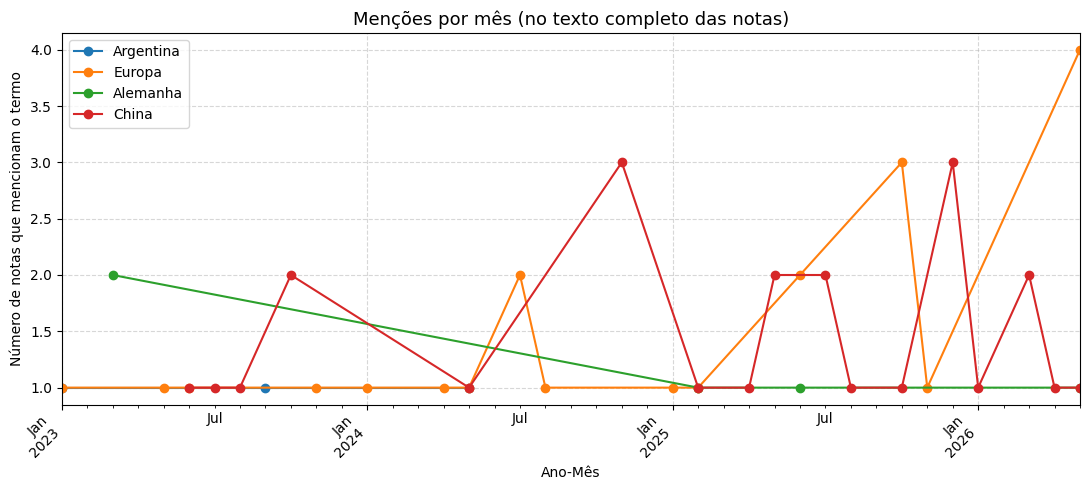

In [ ]:
def evolucao_termo(termo, onde='completo'):
    """Mostra quantas notas mencionam o termo por mês."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    return df[mascara].groupby('ano_mes').size()


# Comparar evolução de vários termos no tempo
termos_comparar = ['Argentina', 'Europa', 'Alemanha', 'China']

fig, ax = plt.subplots(figsize=(11, 5))
for termo in termos_comparar:
    serie = evolucao_termo(termo)
    if len(serie) > 0:
        serie.plot(ax=ax, marker='o', label=termo)

ax.set_title('Menções por mês (no texto completo das notas)', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas que mencionam o termo')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. ☁️ Nuvem de palavras (word cloud)

Forma visual e divertida de ver os termos mais frequentes — quanto maior a palavra, mais ela aparece.

> ⚠️ Precisa instalar a biblioteca `wordcloud` (rode a próxima célula uma vez).


In [ ]:
!pip install wordcloud -q


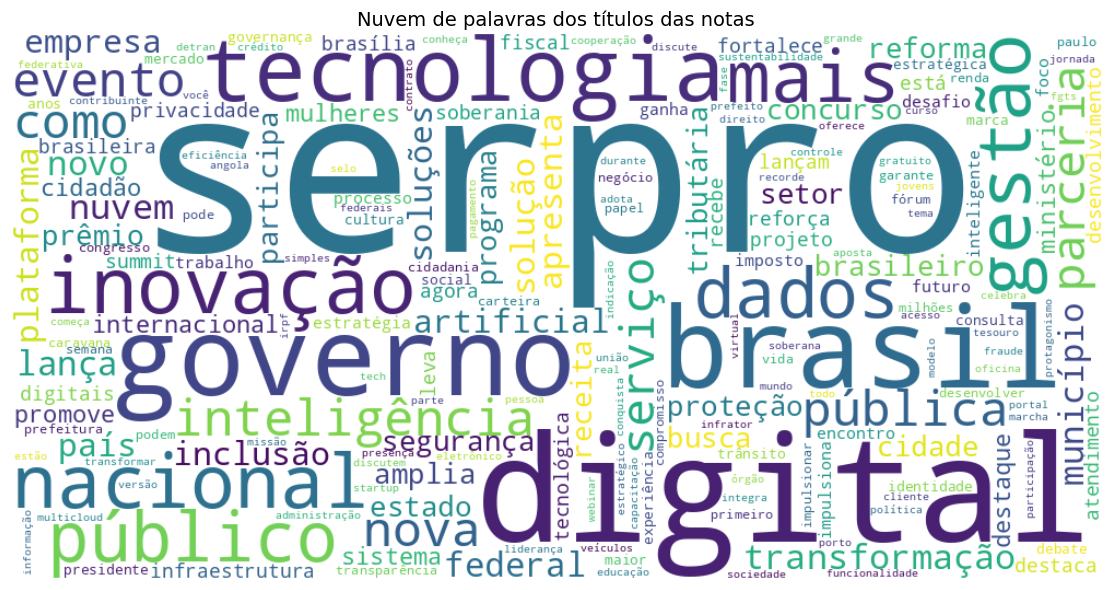

In [ ]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()


## 8. 📏 Tamanho das notas

Quanto texto o MRE costuma escrever em cada nota? Algumas notas são bem curtas (ex: cumprimentos), outras são longas (declarações conjuntas, etc.).


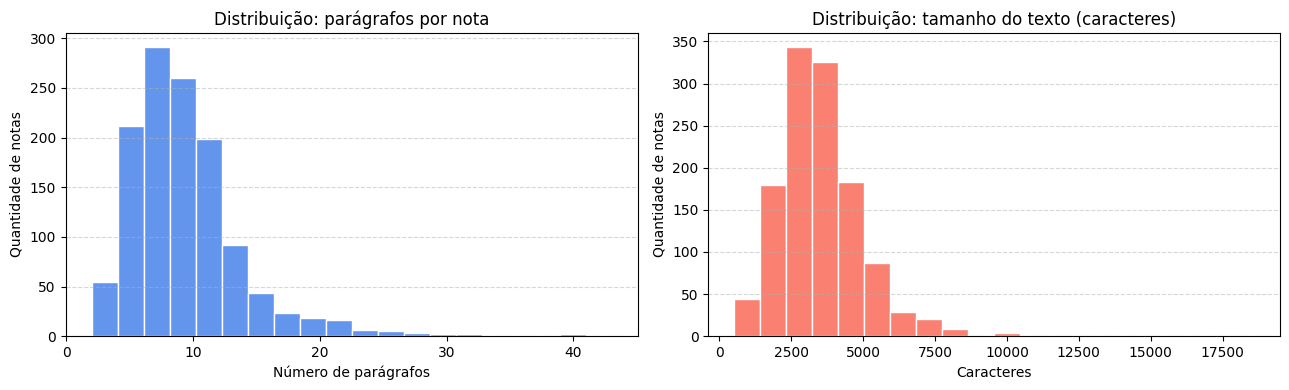


📊 Estatísticas:
       qtd_paragrafo  tamanho_texto
count         1231.0         1231.0
mean             9.7         3570.1
std              4.4         1581.3
min              2.0          516.0
25%              7.0         2543.5
50%              9.0         3369.0
75%             12.0         4292.0
max             43.0        18593.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de quantidade de parágrafos
df['qtd_paragrafo'].plot(kind='hist', bins=20, ax=axes[0], color='cornflowerblue', edgecolor='white')
axes[0].set_title('Distribuição: parágrafos por nota')
axes[0].set_xlabel('Número de parágrafos')
axes[0].set_ylabel('Quantidade de notas')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Histograma de tamanho do texto (em caracteres)
df['tamanho_texto'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Distribuição: tamanho do texto (caracteres)')
axes[1].set_xlabel('Caracteres')
axes[1].set_ylabel('Quantidade de notas')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas:")
print(df[['qtd_paragrafo', 'tamanho_texto']].describe().round(1))


## 9. 🔗 Co-ocorrência de países

Quais países aparecem **juntos** numa mesma nota? Isso revela parcerias diplomáticas e contextos compartilhados (ex: declarações conjuntas).


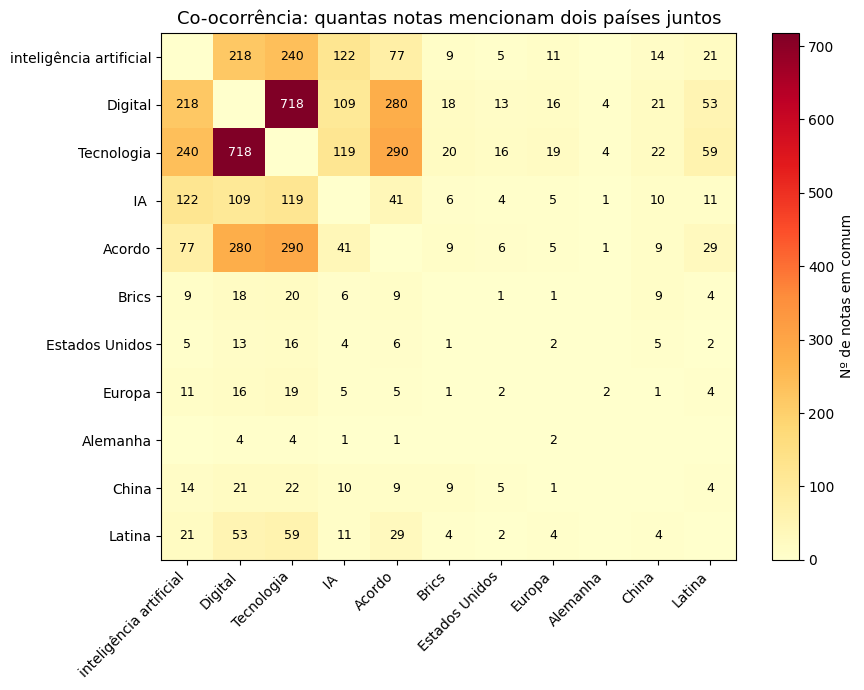

In [ ]:
import numpy as np

paises_analise = ['inteligência artificial', 'Digital', 'Tecnologia', ' IA ', 'Acordo', 'Brics',
                  'Estados Unidos', 'Europa', 'Alemanha', 'China', 'Latina']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    pais: df['texto_completo'].str.contains(pais, case=False, na=False, regex=False).astype(int)
    for pais in paises_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(paises_analise)))
ax.set_yticks(range(len(paises_analise)))
ax.set_xticklabels(paises_analise, rotation=45, ha='right')
ax.set_yticklabels(paises_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam dois países juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(paises_analise)):
    for j in range(len(paises_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()
